In [45]:
### Bone to predict:
BONE = 'tibia'

### Change to older model that does not record the CT_PO:
OLDER_MACHINE = True

USE_WEIGHTED = False

In [46]:
import pandas as pd
import numpy as np
import pickle
from binarize_grades import binarize_grades
from sklearn.discriminant_analysis import StandardScaler


In [ ]:
data = pd.read_excel("data/Gradings XLH + TIO.xlsx", sheet_name="XCT1" if OLDER_MACHINE else "XCT2")
data.head()

In [48]:
radius_rows = data['Site1'].str.contains('Radius')
tibia_rows = data['Site1'].str.contains('Tibia')

In [49]:
pred_cols = ['Tt.BMD', 'Tt.Ar', 'Tb.BMD', 'BV/TV', 'Tb.N', 'Tb.Th', 'Tb.Sp', 'Tb.1/N.SD', 'Tb.Ar', 'Ct.BMD', 'Ct.Th', 'Ct.Po', 'Ct.Po.Dm', 'Ct.Pm', 'Ct.Ar']
if OLDER_MACHINE:
    pred_cols.remove('Ct.Po')
    pred_cols.remove('Ct.Po.Dm')
col_map_xct2 = {'Tb.1/N.SD1': 'Tb.1/N.SD', 
           'Tb.Sp1': 'Tb.Sp', 
           'Tb.Th1': 'Tb.Th', 
           'Tb.N1': 'Tb.N', 
           'Tb.Ar1': 'Tb.Ar', 
           'Tb.BV/TV1': 'BV/TV', 
           'Ct.Pm1': 'Ct.Pm', 
           'Ct.Th1': 'Ct.Th', 
           'Ct.Ar1': 'Ct.Ar',
           'Tot.vBMD1': 'Tt.BMD', 
           'Tb.vBMD1': 'Tb.BMD', 
           'Ct.vBMD1': 'Ct.BMD', 
           'Ct.Po1': 'Ct.Po', 
           'Ct.Po.Dm1': 'Ct.Po.Dm',
           'Tt.Ar1': 'Tt.Ar',
           }

col_map_xct1 = {'tTb.1/N.SD1': 'Tb.1/N.SD', 
                'tTb.Sp1': 'Tb.Sp',
                'tTb.Th1': 'Tb.Th',
                'tTb.N1': 'Tb.N',
                'TrabArea1': 'Tb.Ar',
                'CortArea1': 'Ct.Ar',
                'tBV/TV1': 'BV/TV',
                'Ct.Pm1': 'Ct.Pm',
                'Ct.Th1': 'Ct.Th',
                'D100-1': 'Tt.BMD',
                'Tt.Ar1': 'Tt.Ar',
                'Dtrab1': 'Tb.BMD',
                'Dcomp1': 'Ct.BMD',
                }

col_map = col_map_xct1 if OLDER_MACHINE else col_map_xct2

data = data.rename(columns=col_map)


print(f"{'From':<11} --> To")
for key, val in col_map.items():
    print(f"{key:<11} --> {val}")

From        --> To
tTb.1/N.SD1 --> Tb.1/N.SD
tTb.Sp1     --> Tb.Sp
tTb.Th1     --> Tb.Th
tTb.N1      --> Tb.N
TrabArea1   --> Tb.Ar
CortArea1   --> Ct.Ar
tBV/TV1     --> BV/TV
Ct.Pm1      --> Ct.Pm
Ct.Th1      --> Ct.Th
D100-1      --> Tt.BMD
Tt.Ar1      --> Tt.Ar
Dtrab1      --> Tb.BMD
Dcomp1      --> Ct.BMD


In [50]:
measured_data = data[pred_cols]

In [51]:
# filter out the rows that are not tibia or radius
if BONE == 'tibia':
    measured_data = measured_data[tibia_rows].reset_index(drop=True)
else:
    measured_data = measured_data[radius_rows].reset_index(drop=True)

In [52]:
# get the cluster centers for the binarization from the original data to keep the same binarization from the pickles
machine = 'old' if OLDER_MACHINE else 'new'
zero_center, one_center = pickle.load(open(f"data/{BONE}_{machine}_centers.pkl", "rb"))

In [53]:
grades = data['Motion Grading Felix']
grades = grades[tibia_rows if BONE == 'tibia' else radius_rows].reset_index(drop=True)

measured_data = binarize_grades(measured_data, grades, use_centers=(zero_center, one_center))
print(measured_data['cluster'].value_counts())
grade_col_name = 'cluster'

Cluster 0: 15
Cluster 1: 1
Unassigned: 2
cluster
0    16
1     2
Name: count, dtype: int64


In [ ]:
measured_data

In [55]:
y = measured_data[grade_col_name].values
X = measured_data.drop(columns=[grade_col_name]).values
print(X.shape, y.shape)

(18, 13) (18,)


In [56]:
# TODO: change to existing scaler
scaler = pickle.load(open(f"models/{BONE}_{'XCT1' if OLDER_MACHINE else 'XCT2'}_scaler.pkl", "rb"))
X_scaled = scaler.transform(X)

# Load the model
MACHINE = 'old' if OLDER_MACHINE else 'new'
WEIGHTED = 'balanced_' if USE_WEIGHTED else ''
print(f"Loading model: models/{BONE}_{MACHINE}_{WEIGHTED}model.pkl")

model = pickle.load(open(f"models/{BONE}_{MACHINE}_{WEIGHTED}model.pkl", 'rb'))

Loading model: models/tibia_old_model.pkl


In [57]:
# predict the labels
y_pred = model.predict_proba(X_scaled)

final_pred = [1 if x[1] > 0.5 else 0 for x in y_pred]
final_probas = [x[1] if x[1] > 0.5 else 1 - x[1] for x in y_pred]

predictions = pd.DataFrame(columns=['true', 'pred', 'probability', 'correct'])
predictions['true'] = ['pass' if x == 0 else 'fail' for x in y]
predictions['pred'] = ['pass' if x == 0 else 'fail' for x in final_pred]
predictions['probability'] = final_probas
predictions['correct'] = predictions['true'] == predictions['pred']
predictions['original_set'] = 'test'
predictions

,true,pred,probability,correct,original_set
0,pass,pass,0.996710,True,test
1,pass,pass,0.986266,True,test
2,pass,pass,0.999886,True,test
3,fail,pass,0.742015,False,test
4,pass,pass,0.803296,True,test
5,pass,pass,0.962840,True,test
6,pass,pass,0.926653,True,test
7,pass,pass,0.901493,True,test
8,pass,pass,0.999886,True,test
9,pass,pass,0.932134,True,test


In [58]:
# predictions.to_csv(f"predictions/patient_set_{BONE}_{MACHINE}_{WEIGHTED}predictions.csv", index=False)

In [59]:
# get some measurements
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y, final_pred)
precision = precision_score(y, final_pred)
recall = recall_score(y, final_pred)
f1 = f1_score(y, final_pred)
roc_auc = roc_auc_score(y, final_probas)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1: {f1:.2f}")
print(f"ROC AUC: {roc_auc:.2f}")

Accuracy: 0.89
Precision: 0.00
Recall: 0.00
F1: 0.00
ROC AUC: 0.00


/home/elias/.conda/envs/ProBone/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


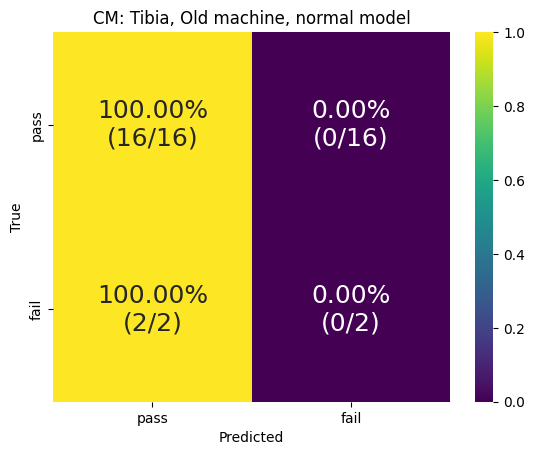

In [60]:
# create confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

balance = 'balanced ' if USE_WEIGHTED else 'normal '

conf_matrix = confusion_matrix(y, final_pred)
percentages = conf_matrix / conf_matrix.sum(axis=1)[:, np.newaxis]

annotations = np.empty_like(conf_matrix, dtype=object)
for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        annotations[i, j] = f"{percentages[i, j]:.2%}\n({conf_matrix[i, j]}/{conf_matrix[i].sum()})"

sns.heatmap(percentages, annot=annotations, fmt='', cmap='viridis', xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], annot_kws={'fontsize': 18})
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'CM: {BONE.capitalize()}, {MACHINE.capitalize()} machine, {balance}model') 
plt.show()
